# MobileVit using AffectNet

In [2]:
# Full end-to-end AffectNet DEFT pipeline for Kaggle
# - Custom dataset reads labels.csv (columns: pth, label, relFCs)
# - Builds DEFT-enabled hybrid MobileNetV2 model
# - Two-phase training, evaluation, and multi-image prediction demo
# Paths assumed:
#   /kaggle/input/affectnet/archive (3)/Train/
#   /kaggle/input/affectnet/archive (3)/Test/
#   /kaggle/input/affectnet/archive (3)/labels.csv

import os
import time
import psutil
import tracemalloc
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ---------------------------
# ==============
#  Config / Paths (customize as needed)
# ==============
LABELS_CSV = "/kaggle/input/affectnet/archive (3)/labels.csv"
TRAIN_ROOT = "/kaggle/input/affectnet/archive (3)/Train"
TEST_ROOT = "/kaggle/input/affectnet/archive (3)/Test"

IMG_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 4                # small default; increase for better performance
PATIENCE = 99
BEST_MODEL_PATH = "/kaggle/working/best_model_mobilenetv2_deft_affectnet.pth"
NUM_WORKERS = 2
RANDOM_SEED = 42
USE_FOCAL_LOSS = False
FUSION_DIM = 512
TRANSFORMER_LAYERS = 4
TRANSFORMER_HEADS = 8
TRANSFORMER_MLP_DIM = 2048
TRANSFORMER_DROPOUT = 0.1
CBAM_SPATIAL_KERNEL = 7
PRIOR_LOSS_WEIGHT = 0.1
# Optional local pretrained backbone weights (if you have them in the dataset)
PRETRAINED_WEIGHTS = "/kaggle/input/v1/other/default/1/mobilenet_v2-b0353104.pth"
# Example: PRETRAINED_WEIGHTS = "/kaggle/input/my-pretrained/mobilenet_v2-b0353104.pth"

# Classes (fixed order) - lowercase to match label strings in your csv sample
CLASS_NAMES = ["anger", "contempt", "disgust", "fear", "happy", "neutral", "sad", "surprise"]
NUM_CLASSES = len(CLASS_NAMES)

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ========================
# 0) Custom dataset for AffectNet (reads labels.csv)
# ========================
class AffectNetDataset(Dataset):
    """
    Expects labels.csv with columns: 'pth' and 'label' (case-insensitive).
    'pth' is a relative path like 'anger/image0000006.jpg'
    root_dir should be the directory containing the Train/ or Test/ images.
    """
    def __init__(self, csv_path, root_dir, split=None, transform=None, classes=CLASS_NAMES):
        """
        csv_path: path to labels.csv
        root_dir: top-level folder that contains image files or subfolders (Train or Test)
        split: optional - if 'Train' or 'Test' - will filter by checking whether file exists under that root
        transform: torchvision transforms
        classes: list of allowed class names
        """
        self.df = pd.read_csv(csv_path)
        # be tolerant: lower-case columns names
        cols = {c.lower(): c for c in self.df.columns}
        if 'pth' in cols:
            pcol = cols['pth']
        elif 'path' in cols:
            pcol = cols['path']
        else:
            raise ValueError("labels.csv must contain a 'pth' column (or 'path'). Found: " + ", ".join(self.df.columns))

        if 'label' in cols:
            lcol = cols['label']
        elif 'expression' in cols:
            lcol = cols['expression']
        else:
            raise ValueError("labels.csv must contain a 'label' column (or 'expression'). Found: " + ", ".join(self.df.columns))

        self.pth_col = pcol
        self.label_col = lcol

        self.root_dir = root_dir
        self.transform = transform
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        # build samples list: full path + label index
        samples = []
        for _, row in self.df.iterrows():
            rel = str(row[self.pth_col]).strip()
            lbl = str(row[self.label_col]).strip().lower()
            if lbl not in self.class_to_idx:
                # skip unknown labels
                continue
            # full path: we assume rel is relative to root_dir, e.g., "anger/image0000006.jpg"
            full = os.path.join(root_dir, rel)
            if split is not None:
                # skip if not under the requested root (helps distinguish Train vs Test)
                if not os.path.exists(full):
                    continue
            else:
                # if split None, still require existence
                if not os.path.exists(full):
                    continue
            samples.append((full, self.class_to_idx[lbl]))

        if len(samples) == 0:
            raise RuntimeError(f"No image samples found under root '{root_dir}' using csv '{csv_path}'. Check paths/filenames.")
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            img = Image.open(path).convert("RGB")
        except Exception as e:
            # fallback: return a black image if file can't be opened (shouldn't happen in Kaggle if files exist)
            print(f"⚠️ Failed to open {path}: {e}. Returning black image.")
            img = Image.new("RGB", (IMG_SIZE, IMG_SIZE), (0, 0, 0))

        if self.transform:
            img = self.transform(img)
        return img, label

# ========================
# 1) Data transforms & datasets
# ========================
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(6),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0), ratio=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

print("📥 Loading datasets (this may take a moment)...")
train_dataset = AffectNetDataset(LABELS_CSV, TRAIN_ROOT, split='Train', transform=transform_train, classes=CLASS_NAMES)
test_dataset = AffectNetDataset(LABELS_CSV, TEST_ROOT, split='Test', transform=transform_test, classes=CLASS_NAMES)

# For validation we will split a small portion off the train dataset
val_size = int(0.1 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(RANDOM_SEED))

print(f"✅ Dataset sizes — Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
print(f"✅ Class names (index order): {CLASS_NAMES}")

# Weighted sampler to address class imbalance (compute from original train CSV entries under TRAIN_ROOT)
# Build counts from the full train_dataset (random_split returns Subset objects)
targets_full = [s[1] for s in train_dataset.dataset.samples] if hasattr(train_dataset, 'dataset') else [s[1] for s in train_dataset.samples]
# If random_split used Subset, we compute counts for indices
if isinstance(train_dataset, torch.utils.data.dataset.Subset):
    full_targets = [train_dataset.dataset.samples[i][1] for i in train_dataset.indices]
else:
    full_targets = targets_full

class_sample_count = Counter(full_targets)
weights_per_class = {cls: 1.0 / count for cls, count in class_sample_count.items()}

# create weights for every sample in the train subset
train_indices = train_dataset.indices if isinstance(train_dataset, torch.utils.data.dataset.Subset) else list(range(len(train_dataset)))
train_targets = [full_targets[i] if isinstance(train_dataset, torch.utils.data.dataset.Subset) else train_dataset[i][1] for i in range(len(train_dataset))]
# safer approach: iterate subset to get labels
train_targets = []
for i in range(len(train_dataset)):
    if isinstance(train_dataset, torch.utils.data.dataset.Subset):
        label = train_dataset.dataset.samples[train_dataset.indices[i]][1]
    else:
        label = train_dataset.samples[i][1]
    train_targets.append(label)

weights = [weights_per_class[t] for t in train_targets]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# ========================
# 2) Attention & Transformer (copied/kept from your DEFT code)
# ========================

class MobileViTBlock(nn.Module):
    """
    MobileViT-style fusion block
    Local convolution + global Transformer + residual fusion
    """
    def __init__(self, dim, depth=2, heads=4, mlp_dim=None, dropout=0.1):
        super().__init__()
        mlp_dim = mlp_dim or dim * 2

        self.conv1 = nn.Conv2d(dim, dim, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(dim)
        self.act = nn.GELU()

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim,
            nhead=heads,
            dim_feedforward=mlp_dim,
            dropout=dropout,
            activation='gelu',
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        self.conv2 = nn.Conv2d(dim, dim, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(dim)

    def forward(self, x):
        residual = x

        x = self.act(self.bn1(self.conv1(x)))
        B, C, H, W = x.shape

        tokens = x.flatten(2).transpose(1, 2)  # (B, HW, C)
        tokens = self.encoder(tokens)

        x = tokens.transpose(1, 2).view(B, C, H, W)
        x = self.bn2(self.conv2(x))

        return x + residual


class SELayer(nn.Module):
    def __init__(self, channel, reduction=16):
        super(SELayer, self).__init__()
        mid = max(1, channel // reduction)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, mid, bias=True),
            nn.ReLU(inplace=True),
            nn.Linear(mid, channel, bias=True),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, spatial_kernel=7):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False),
            nn.Sigmoid()
        )
        self.spatial = nn.Sequential(
            nn.Conv2d(2, 1, kernel_size=spatial_kernel, padding=spatial_kernel // 2, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        ca = self.mlp(x)
        x = x * ca
        sa = self.spatial(torch.cat([x.mean(1, keepdim=True), x.max(1, keepdim=True)[0]], dim=1))
        x = x * sa
        return x

class TransformerFusion(nn.Module):
    def __init__(self, dim, depth=6, heads=8, mlp_dim=2048, dropout=0.1):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim, nhead=heads, dim_feedforward=mlp_dim,
            dropout=dropout, activation='gelu', batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
    def forward(self, x):
        return self.encoder(x)

class EmotionAdaptiveFusion(nn.Module):
    def __init__(self, dim, depth=4, heads=8, mlp_dim=2048, dropout=0.1):
        super().__init__()
        self.dim = dim
        self.global_fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(dim, max(8, dim // 4), 1),
            nn.GELU(),
            nn.Conv2d(max(8, dim // 4), dim, 1),
            nn.Sigmoid()
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim, nhead=heads, dim_feedforward=mlp_dim,
            dropout=dropout, activation='gelu', batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.gate_fc = nn.Sequential(
            nn.Linear(dim, dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        B, C, H, W = x.shape
        x = F.avg_pool2d(x, kernel_size=2)
        H, W = x.shape[2], x.shape[3]
        g = self.global_fc(x)
        x_mod = x * g
        tokens = x_mod.flatten(2).transpose(1, 2)
        fused = self.encoder(tokens)
        global_token = fused.mean(1)
        gate = self.gate_fc(global_token).unsqueeze(-1).unsqueeze(-1)
        fused_map = fused.transpose(1, 2).view(B, C, H, W)
        out = fused_map * gate + x_mod * (1 - gate)
        return out

class EmotionPriorHead(nn.Module):
    def __init__(self, in_dim, num_classes):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(in_dim, num_classes)
        )
    def forward(self, x):
        return self.fc(x)

class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce = nn.CrossEntropyLoss(reduction='none')
    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return loss.mean() if self.reduction == 'mean' else loss.sum()

# ========================
# 3) Build Hybrid Model with DEFT
# ========================
def build_hybrid_mobilenetv2_deft(num_classes,
                                  pretrained_path=None,
                                  se_reduction=16,
                                  fusion_dim=FUSION_DIM,
                                  transformer_layers=TRANSFORMER_LAYERS,
                                  transformer_heads=TRANSFORMER_HEADS,
                                  transformer_mlp_dim=TRANSFORMER_MLP_DIM,
                                  transformer_dropout=TRANSFORMER_DROPOUT,
                                  cbam_spatial_kernel=CBAM_SPATIAL_KERNEL,
                                  dropout_p=0.4,
                                  use_aux_prior=True,
                                  ablation="deft"):
    # instantiate backbone
    try:
        backbone_model = models.mobilenet_v2(weights=None)
    except Exception:
        backbone_model = models.mobilenet_v2(weights=None)

    # attempt to load optional local weights
    if pretrained_path and os.path.exists(pretrained_path):
        try:
            print(f"🔹 Loading local pretrained weights from: {pretrained_path}")
            state_dict = torch.load(pretrained_path, map_location="cpu")
            state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
            backbone_model.load_state_dict(state_dict, strict=False)
        except Exception as e:
            print(f"⚠️ Failed to load local backbone weights: {e}. Continuing from scratch.")
    else:
        print("ℹ️ No local pretrained backbone weights found or path not provided — backbone initialized from scratch.")

    backbone = backbone_model.features
    backbone_out_channels = backbone_model.last_channel

    se_block = SELayer(backbone_out_channels, reduction=se_reduction)

    proj_conv = nn.Conv2d(backbone_out_channels, fusion_dim, kernel_size=1, bias=False)
    proj_bn = nn.BatchNorm2d(fusion_dim)
    proj_relu = nn.ReLU(inplace=True)

    if ablation == "deft":
        fusion_module = MobileViTBlock(
                                        dim=fusion_dim,
                                        depth=2,
                                        heads=4,
                                        mlp_dim=fusion_dim * 2,
                                        dropout=transformer_dropout
                                    )
        cbam_module = None

    elif ablation == "static":
        fusion_module = TransformerFusion(dim=fusion_dim,
                                          depth=transformer_layers,
                                          heads=transformer_heads,
                                          mlp_dim=transformer_mlp_dim,
                                          dropout=transformer_dropout)
        cbam_module = CBAM(channels=fusion_dim, reduction=16, spatial_kernel=cbam_spatial_kernel)
    else:
        fusion_module = None
        cbam_module = CBAM(channels=fusion_dim, reduction=16, spatial_kernel=cbam_spatial_kernel)

    max_tokens = 49
    pos_embed = nn.Parameter(torch.zeros(1, max_tokens, fusion_dim))

    head = nn.Sequential(
        nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.Dropout(p=dropout_p),
        nn.Linear(fusion_dim, 512, bias=True),
        nn.BatchNorm1d(512),
        nn.GELU(),
        nn.Linear(512, num_classes, bias=True)
    )

    prior_head = EmotionPriorHead(backbone_out_channels, num_classes) if use_aux_prior else None

    class HybridModel(nn.Module):
        def __init__(self):
            super().__init__()
            self.backbone = backbone
            self.se = se_block
            self.proj_conv = proj_conv
            self.proj_bn = proj_bn
            self.proj_relu = proj_relu
            self.fusion = fusion_module
            self.cbam = cbam_module
            self.pos_embed = pos_embed
            self.head = head
            self.prior_head = prior_head
            self.fusion_dim = fusion_dim
            self.ablation = ablation

        def forward(self, x, return_prior=False):
            feat = self.backbone(x)
            se_feat = self.se(feat)
            fused = self.proj_conv(se_feat)
            fused = self.proj_bn(fused)
            fused = self.proj_relu(fused)
            b, c, h, w = fused.shape
            n = h * w

            if self.ablation == "none":
                if self.cbam is not None:
                    refined = self.cbam(fused)
                else:
                    refined = fused
            else:
                if isinstance(self.fusion, MobileViTBlock):
                    refined = self.fusion(fused)
                elif isinstance(self.fusion, TransformerFusion):
                    tokens = fused.flatten(2).transpose(1, 2)
                    if n <= self.pos_embed.shape[1]:
                        pos = self.pos_embed[:, :n, :].expand(b, -1, -1)
                    else:
                        pos = nn.functional.interpolate(self.pos_embed.transpose(1,2),
                                                        size=n).transpose(1,2).expand(b, -1, -1)
                    tokens = tokens + pos
                    tokens = self.fusion(tokens)
                    fused2 = tokens.transpose(1, 2).view(b, c, h, w)
                    if self.cbam is not None:
                        refined = self.cbam(fused2)
                    else:
                        refined = fused2
                else:
                    refined = fused

            logits = self.head(refined)

            prior_logits = None
            if self.prior_head is not None:
                prior_logits = self.prior_head(se_feat)

            if return_prior:
                return logits, prior_logits
            else:
                return logits

    model = HybridModel()

    # head initialization
    for m in model.head.modules():
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.BatchNorm1d):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

    return model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_hybrid_mobilenetv2_deft(num_classes=NUM_CLASSES,
                                      pretrained_path=PRETRAINED_WEIGHTS,
                                      se_reduction=16,
                                      fusion_dim=FUSION_DIM,
                                      transformer_layers=TRANSFORMER_LAYERS,
                                      transformer_heads=TRANSFORMER_HEADS,
                                      transformer_mlp_dim=TRANSFORMER_MLP_DIM,
                                      transformer_dropout=TRANSFORMER_DROPOUT,
                                      cbam_spatial_kernel=CBAM_SPATIAL_KERNEL,
                                      dropout_p=0.4,
                                      use_aux_prior=True,
                                      ablation="deft").to(device)
print(f"✅ Hybrid DEFT model created. Device: {device}")

# ========================
# 4) Loss, optimizer, scheduler, AMP scaler
# ========================
# compute class weights from training set
# Fetch labels for train_dataset (Subset may be used)
train_labels_for_weights = []
for i in range(len(train_dataset)):
    img, lbl = train_dataset[i]
    train_labels_for_weights.append(int(lbl))
counts = Counter(train_labels_for_weights)
class_weights = torch.tensor([counts[i] if i in counts else 1 for i in range(NUM_CLASSES)], dtype=torch.float)
class_weights = class_weights.sum() / (class_weights + 1e-12)
class_weights = class_weights.to(device)

label_smoothing = 0.1

if USE_FOCAL_LOSS:
    criterion = FocalLoss(alpha=1.0, gamma=2.0)
    print("🔹 Using FocalLoss")
else:
    try:
        criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=label_smoothing)
        print("🔹 Using CrossEntropyLoss with label smoothing")
    except TypeError:
        print("⚠️ label_smoothing not supported in this PyTorch version. Using plain CrossEntropyLoss.")
        criterion = nn.CrossEntropyLoss(weight=class_weights)

scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

# ========================
# Utility functions: train/validate/save/load
# ========================
def train_one_epoch(model, loader, optimizer, scheduler, epoch, max_grad_norm=5.0):
    model.train()
    total_loss = 0.0
    progress_bar = tqdm(loader, desc=f"Training Epoch {epoch+1}", leave=False)
    for imgs, labels in progress_bar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            if getattr(model, 'prior_head', None) is not None:
                outputs, prior_logits = model(imgs, return_prior=True)
            else:
                outputs = model(imgs)
                prior_logits = None

            loss_main = criterion(outputs, labels)

            if prior_logits is not None:
                log_p = F.log_softmax(prior_logits, dim=1)
                target_onehot = F.one_hot(labels, NUM_CLASSES).float()
                smooth_eps = 0.05
                target_smooth = target_onehot * (1 - smooth_eps) + smooth_eps / NUM_CLASSES
                kl_loss = F.kl_div(log_p, target_smooth, reduction='batchmean')
                loss = loss_main + PRIOR_LOSS_WEIGHT * kl_loss

            else:
                loss = loss_main

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        scaler.step(optimizer)
        scaler.update()
        if scheduler is not None:
            scheduler.step()
        total_loss += loss.item()
        progress_bar.set_postfix(loss=float(loss.item()))
    return total_loss / len(loader)

def validate(model, loader, epoch, phase="Validation"):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                if getattr(model, 'prior_head', None) is not None:
                    outputs, _ = model(imgs, return_prior=True)
                else:
                    outputs = model(imgs)
                loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    acc = 100.0 * correct / total if total > 0 else 0.0
    return total_loss / len(loader), acc

def save_best_model(model, path):
    torch.save(model.state_dict(), path)
    print(f"💾 Best model saved to {path}")

def load_best_model(model, path):
    model.load_state_dict(torch.load(path, map_location=device))
    print(f"✅ Best model loaded from {path}")

# ========================
# 5) Two-phase training
# ========================
# Phase 1: train head only
for name, param in model.named_parameters():
    if "head" in name or "prior_head" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

head_params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.AdamW(head_params, lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=max(1, EPOCHS), T_mult=1)

# Resource tracking start
print("\n📊 Starting resource tracking...\n")
process = psutil.Process(os.getpid())
tracemalloc.start()
start_cpu_percent = process.cpu_percent(interval=1)
start_mem_info = process.memory_info()

training_start_time = time.time()
print("\n🚀 Phase 1: Training classifier only...\n")
best_val_acc, patience_counter = 0.0, 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, epoch)
    val_loss, val_acc = validate(model, val_loader, epoch)
    print(f"Phase1 Epoch {epoch+1}: Train Loss={train_loss:.4f} | Val Acc={val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        save_best_model(model, BEST_MODEL_PATH)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("⏸️ Early stopping triggered (Phase 1).")
            break

# Load best from phase 1
if os.path.exists(BEST_MODEL_PATH):
    load_best_model(model, BEST_MODEL_PATH)

# Phase 2: unfreeze & fine-tune whole model
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=max(1, EPOCHS), T_mult=1)

print("\n📢 Phase 2: Fine-tuning full model...\n")
best_val_acc, patience_counter = 0.0, 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, epoch)
    val_loss, val_acc = validate(model, val_loader, epoch, phase="Fine-tuning")
    print(f"Fine-tune Epoch {epoch+1}: Train Loss={train_loss:.4f} | Val Acc={val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        save_best_model(model, BEST_MODEL_PATH)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("⏸️ Early stopping triggered (Phase 2).")
            break

# load final best
if os.path.exists(BEST_MODEL_PATH):
    load_best_model(model, BEST_MODEL_PATH)

training_end_time = time.time()
total_training_time = training_end_time - training_start_time
print(f"\n⏱️ Total Training Time (Phases 1 & 2): {total_training_time:.2f} seconds")

# Resource usage end
end_cpu_percent = process.cpu_percent(interval=1)
end_mem_info = process.memory_info()
current_mem, peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"🧠 Memory Usage Before Training: {start_mem_info.rss / (1024 * 1024):.2f} MB")
print(f"🧠 Memory Usage After Training: {end_mem_info.rss / (1024 * 1024):.2f} MB")
print(f"📈 Peak Memory Used: {peak_mem / (1024 * 1024):.2f} MB")
print(f"⚙️ CPU Utilization at End: {end_cpu_percent:.2f}%")

# ========================
# 6) Testing & Evaluation
# ========================
testing_start_time = time.time()
model.eval()
correct, total = 0, 0
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="🧪 Testing", leave=True):
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            if getattr(model, 'prior_head', None) is not None:
                outputs, _ = model(imgs, return_prior=True)
            else:
                outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

testing_end_time = time.time()
testing_time = testing_end_time - testing_start_time
print(f"\n⏱️ Total Testing Time: {testing_time:.2f} seconds")

test_acc = 100.0 * correct / total if total > 0 else 0.0
print(f"\n🎯 Test Accuracy: {test_acc:.2f}%")

eval_cpu_percent = process.cpu_percent(interval=1)
eval_mem_info = process.memory_info()
print(f"\n📊 [Evaluation] CPU Usage: {eval_cpu_percent:.2f}%")
print(f"📊 [Evaluation] Memory Usage: {eval_mem_info.rss / (1024 * 1024):.2f} MB")

# Per-class metrics and bar plot
def calculate_metrics_from_cm(cm, class_names):
    total = cm.sum()
    sensitivity_list, specificity_list, efficiency_list = [], [], []
    for i, cls in enumerate(class_names):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = total - TP - FP - FN
        sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
        efficiency = (sensitivity + specificity) / 2.0
        sensitivity_list.append(sensitivity)
        specificity_list.append(specificity)
        efficiency_list.append(efficiency)
        print(f"\nClass: {cls}")
        print(f"  Sensitivity (Recall):  {sensitivity:.4f}")
        print(f"  Specificity:           {specificity:.4f}")
        print(f"  Efficiency:            {efficiency:.4f}")

    x = np.arange(len(class_names))
    width = 0.25
    plt.figure(figsize=(12, 6))
    plt.bar(x - width, sensitivity_list, width=width, label='Sensitivity')
    plt.bar(x, specificity_list, width=width, label='Specificity')
    plt.bar(x + width, efficiency_list, width=width, label='Efficiency')
    plt.xticks(ticks=x, labels=class_names, rotation=45)
    plt.xlabel("Emotion Class")
    plt.ylabel("Metric Value")
    plt.title("Per-class Metrics")
    plt.legend()
    plt.tight_layout()
    plt.show()

calculate_metrics_from_cm(cm, class_names)


# ========================
# 7) Confusion matrix & report
# ========================
print("\n📊 Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-12)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlGnBu', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Normalized Confusion Matrix (AffectNet DEFT)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Per-class metrics and bar plot (sensitivity, specificity, efficiency)
def calculate_metrics_from_cm(cm, class_names):
    total = cm.sum()
    sensitivity_list, specificity_list, efficiency_list = [], [], []
    for i, cls in enumerate(class_names):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = total - TP - FP - FN
        sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
        efficiency = (sensitivity + specificity) / 2.0
        sensitivity_list.append(sensitivity)
        specificity_list.append(specificity)
        efficiency_list.append(efficiency)
        print(f"\nClass: {cls}")
        print(f"  Sensitivity (Recall):  {sensitivity:.4f}")
        print(f"  Specificity:           {specificity:.4f}")
        print(f"  Efficiency:            {efficiency:.4f}")

    x = np.arange(len(class_names))
    width = 0.25
    plt.figure(figsize=(12, 6))
    plt.bar(x - width, sensitivity_list, width=width, label='Sensitivity')
    plt.bar(x, specificity_list, width=width, label='Specificity')
    plt.bar(x + width, efficiency_list, width=width, label='Efficiency')
    plt.xticks(ticks=x, labels=class_names, rotation=45)
    plt.xlabel("Emotion Class")
    plt.ylabel("Metric Value")
    plt.title("Sensitivity, Specificity, Efficiency per Class (FER2013 DEFT)")
    plt.legend()
    plt.tight_layout()
    plt.show()

calculate_metrics_from_cm(cm, class_names)


# ========================
# 8) Small demo: multiple image prediction (your provided paths)
# ========================
image_paths = [
    "/kaggle/input/affectnet/archive (3)/Test/Anger/image0000006.jpg",
    "/kaggle/input/affectnet/archive (3)/Test/Anger/image0000060.jpg",
    "/kaggle/input/affectnet/archive (3)/Test/Anger/image0000061.jpg",
    "/kaggle/input/affectnet/archive (3)/Test/Contempt/ffhq_1.png",
    "/kaggle/input/affectnet/archive (3)/Test/Contempt/ffhq_10.png",
    "/kaggle/input/affectnet/archive (3)/Test/Contempt/ffhq_100.png",
    "/kaggle/input/affectnet/archive (3)/Test/disgust/ffhq_0.png",
    "/kaggle/input/affectnet/archive (3)/Test/disgust/ffhq_1.png",
    "/kaggle/input/affectnet/archive (3)/Test/disgust/ffhq_10.png",
    "/kaggle/input/affectnet/archive (3)/Test/fear/image0000284.jpg",
    "/kaggle/input/affectnet/archive (3)/Test/fear/image0000285.jpg",
    "/kaggle/input/affectnet/archive (3)/Test/fear/image0000419.jpg",
    "/kaggle/input/affectnet/archive (3)/Test/happy/ffhq_0.png",
    "/kaggle/input/affectnet/archive (3)/Test/happy/ffhq_1.png",
    "/kaggle/input/affectnet/archive (3)/Test/happy/ffhq_10.png",
    "/kaggle/input/affectnet/archive (3)/Test/neutral/ffhq_0.png",
    "/kaggle/input/affectnet/archive (3)/Test/neutral/ffhq_0.png",
    "/kaggle/input/affectnet/archive (3)/Test/neutral/ffhq_10.png",
    "/kaggle/input/affectnet/archive (3)/Test/sad/image0000013.jpg",
    "/kaggle/input/affectnet/archive (3)/Test/sad/image0000027.jpg",
    "/kaggle/input/affectnet/archive (3)/Test/sad/image0000028.jpg",
    "/kaggle/input/affectnet/archive (3)/Test/surprise/ffhq_1.png",
    "/kaggle/input/affectnet/archive (3)/Test/surprise/ffhq_10.png",
    "/kaggle/input/affectnet/archive (3)/Test/surprise/ffhq_100.png",
]

transform_multi = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

images, valid_paths = [], []
for path in image_paths:
    try:
        img = Image.open(path).convert("RGB")
        img = transform_multi(img)
        images.append(img)
        valid_paths.append(path)
    except Exception as e:
        print(f"⚠️ Skipping {path}: {e}")

if images:
    images_tensor = torch.stack(images).to(device)
    model.eval()
    with torch.no_grad():
        if getattr(model, 'prior_head', None) is not None:
            outputs, priors = model(images_tensor, return_prior=True)
        else:
            outputs = model(images_tensor)
        _, preds = torch.max(outputs, 1)

    print("\n========== Emotion Predictions ==========")
    for img_path, pred_idx in zip(valid_paths, preds):
        predicted_emotion = CLASS_NAMES[pred_idx.item()]
        true_emotion = os.path.basename(os.path.dirname(img_path)).lower()
        print(f"{true_emotion} → {predicted_emotion}")
    print("=========================================")
else:
    print("❌ No valid images found for manual prediction demo.")


📥 Loading datasets (this may take a moment)...
✅ Dataset sizes — Train: 14022, Val: 1557, Test: 11206
✅ Class names (index order): ['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
🔹 Loading local pretrained weights from: /kaggle/input/v1/other/default/1/mobilenet_v2-b0353104.pth
✅ Hybrid DEFT model created. Device: cpu
🔹 Using CrossEntropyLoss with label smoothing

📊 Starting resource tracking...



/tmp/ipykernel_47/2273417532.py:558: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))



🚀 Phase 1: Training classifier only...



Training Epoch 1:   0%|          | 0/220 [00:00<?, ?it/s]/tmp/ipykernel_47/2273417532.py:570: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
/tmp/ipykernel_47/2273417532.py:607: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Phase1 Epoch 1: Train Loss=2.0592 | Val Acc=31.73%
💾 Best model saved to /kaggle/working/best_model_mobilenetv2_deft_affectnet.pth


...

Fine-tune Epoch 3: Train Loss=1.2005 | Val Acc=60.95%
💾 Best model saved to /kaggle/working/best_model_mobilenetv2_deft_affectnet.pth


Fine-tune Epoch 4: Train Loss=1.1101 | Val Acc=63.90%
💾 Best model saved to /kaggle/working/best_model_mobilenetv2_deft_affectnet.pth
✅ Best model loaded from /kaggle/working/best_model_mobilenetv2_deft_affectnet.pth

⏱️ Total Training Time (Phases 1 & 2): 11441.17 seconds
🧠 Memory Usage Before Training: 1032.41 MB
🧠 Memory Usage After Training: 5168.09 MB
📈 Peak Memory Used: 16.07 MB
⚙️ CPU Utilization at End: 2.00%


🧪 Testing:   0%|          | 0/176 [00:00<?, ?it/s]/tmp/ipykernel_47/2273417532.py:727: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
🧪 Testing: 100%|██████████| 176/176 [05:07<00:00,  1.75s/it]



⏱️ Total Testing Time: 307.28 seconds

🎯 Test Accuracy: 66.12%

📊 [Evaluation] CPU Usage: 0.00%
📊 [Evaluation] Memory Usage: 5171.54 MB


NameError: name 'cm' is not defined

In [3]:
# ========================
# 8) Small demo: multiple image prediction (your provided paths)
# ========================
image_paths = [
    "/kaggle/input/affectnet/archive (3)/Test/Anger/image0000006.jpg",
    "/kaggle/input/affectnet/archive (3)/Test/Anger/image0000060.jpg",
    "/kaggle/input/affectnet/archive (3)/Test/Anger/image0000061.jpg",
    "/kaggle/input/affectnet/archive (3)/Test/Contempt/ffhq_1.png",
    "/kaggle/input/affectnet/archive (3)/Test/Contempt/ffhq_10.png",
    "/kaggle/input/affectnet/archive (3)/Test/Contempt/ffhq_100.png",
    "/kaggle/input/affectnet/archive (3)/Test/disgust/ffhq_0.png",
    "/kaggle/input/affectnet/archive (3)/Test/disgust/ffhq_1.png",
    "/kaggle/input/affectnet/archive (3)/Test/disgust/ffhq_10.png",
    "/kaggle/input/affectnet/archive (3)/Test/fear/image0000284.jpg",
    "/kaggle/input/affectnet/archive (3)/Test/fear/image0000285.jpg",
    "/kaggle/input/affectnet/archive (3)/Test/fear/image0000419.jpg",
    "/kaggle/input/affectnet/archive (3)/Test/happy/ffhq_0.png",
    "/kaggle/input/affectnet/archive (3)/Test/happy/ffhq_1.png",
    "/kaggle/input/affectnet/archive (3)/Test/happy/ffhq_10.png",
    "/kaggle/input/affectnet/archive (3)/Test/neutral/ffhq_0.png",
    "/kaggle/input/affectnet/archive (3)/Test/neutral/ffhq_0.png",
    "/kaggle/input/affectnet/archive (3)/Test/neutral/ffhq_10.png",
    "/kaggle/input/affectnet/archive (3)/Test/sad/image0000013.jpg",
    "/kaggle/input/affectnet/archive (3)/Test/sad/image0000027.jpg",
    "/kaggle/input/affectnet/archive (3)/Test/sad/image0000028.jpg",
    "/kaggle/input/affectnet/archive (3)/Test/surprise/ffhq_1.png",
    "/kaggle/input/affectnet/archive (3)/Test/surprise/ffhq_10.png",
    "/kaggle/input/affectnet/archive (3)/Test/surprise/ffhq_100.png",
]

transform_multi = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

images, valid_paths = [], []
for path in image_paths:
    try:
        img = Image.open(path).convert("RGB")
        img = transform_multi(img)
        images.append(img)
        valid_paths.append(path)
    except Exception as e:
        print(f"⚠️ Skipping {path}: {e}")

if images:
    images_tensor = torch.stack(images).to(device)
    model.eval()
    with torch.no_grad():
        if getattr(model, 'prior_head', None) is not None:
            outputs, priors = model(images_tensor, return_prior=True)
        else:
            outputs = model(images_tensor)
        _, preds = torch.max(outputs, 1)

    print("\n========== Emotion Predictions ==========")
    for img_path, pred_idx in zip(valid_paths, preds):
        predicted_emotion = CLASS_NAMES[pred_idx.item()]
        true_emotion = os.path.basename(os.path.dirname(img_path)).lower()
        print(f"{true_emotion} → {predicted_emotion}")
    print("=========================================")
else:
    print("❌ No valid images found for manual prediction demo.")



========== Emotion Predictions ==========
anger → surprise
anger → contempt
anger → disgust
contempt → contempt
contempt → disgust
contempt → contempt
disgust → neutral
disgust → disgust
disgust → disgust
fear → fear
fear → neutral
fear → fear
happy → happy
happy → happy
happy → happy
neutral → neutral
neutral → neutral
neutral → neutral
sad → sad
sad → anger
sad → anger
surprise → surprise
surprise → surprise
surprise → contempt


In [4]:
# Per-class metrics and bar plot (sensitivity, specificity, efficiency)
def calculate_metrics_from_cm(cm, class_names):
    total = cm.sum()
    sensitivity_list, specificity_list, efficiency_list = [], [], []
    for i, cls in enumerate(class_names):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = total - TP - FP - FN
        sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
        efficiency = (sensitivity + specificity) / 2.0
        sensitivity_list.append(sensitivity)
        specificity_list.append(specificity)
        efficiency_list.append(efficiency)
        print(f"\nClass: {cls}")
        print(f"  Sensitivity (Recall):  {sensitivity:.4f}")
        print(f"  Specificity:           {specificity:.4f}")
        print(f"  Efficiency:            {efficiency:.4f}")

    x = np.arange(len(class_names))
    width = 0.25
    plt.figure(figsize=(12, 6))
    plt.bar(x - width, sensitivity_list, width=width, label='Sensitivity')
    plt.bar(x, specificity_list, width=width, label='Specificity')
    plt.bar(x + width, efficiency_list, width=width, label='Efficiency')
    plt.xticks(ticks=x, labels=class_names, rotation=45)
    plt.xlabel("Emotion Class")
    plt.ylabel("Metric Value")
    plt.title("Sensitivity, Specificity, Efficiency per Class (AffectNet DEFT)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Only calculate metrics if confusion matrix exists and has the correct shape
if 'cm' in locals() and cm.size == (NUM_CLASSES, NUM_CLASSES):
    calculate_metrics_from_cm(cm, CLASS_NAMES)
else:
    print("⚠️ Confusion matrix 'cm' not available or has unexpected shape; skipping per-class metric plot.")


⚠️ Confusion matrix 'cm' not available or has unexpected shape; skipping per-class metric plot.


Confusion matrix shape: (8, 8)

Classification Report:
              precision    recall  f1-score   support

       Anger     0.5116    0.4478    0.4776       690
    Contempt     0.5068    0.4575    0.4809       647
     Disgust     0.6815    0.6070    0.6421      1509
        Fear     0.6389    0.7026    0.6692      1483
       Happy     0.8299    0.8972    0.8622      2159
     Neutral     0.4519    0.7903    0.5750      1154
         Sad     0.7648    0.5347    0.6294      1399
    Surprise     0.7291    0.5769    0.6441      2165

    accuracy                         0.6612     11206
   macro avg     0.6393    0.6268    0.6226     11206
weighted avg     0.6799    0.6612    0.6606     11206


Class: Anger
  Sensitivity (Recall):  0.4478
  Specificity:           0.9719
  Efficiency:            0.7099

Class: Contempt
  Sensitivity (Recall):  0.4575
  Specificity:           0.9727
  Efficiency:            0.7151

Class: Disgust
  Sensitivity (Recall):  0.6070
  Specificity:         

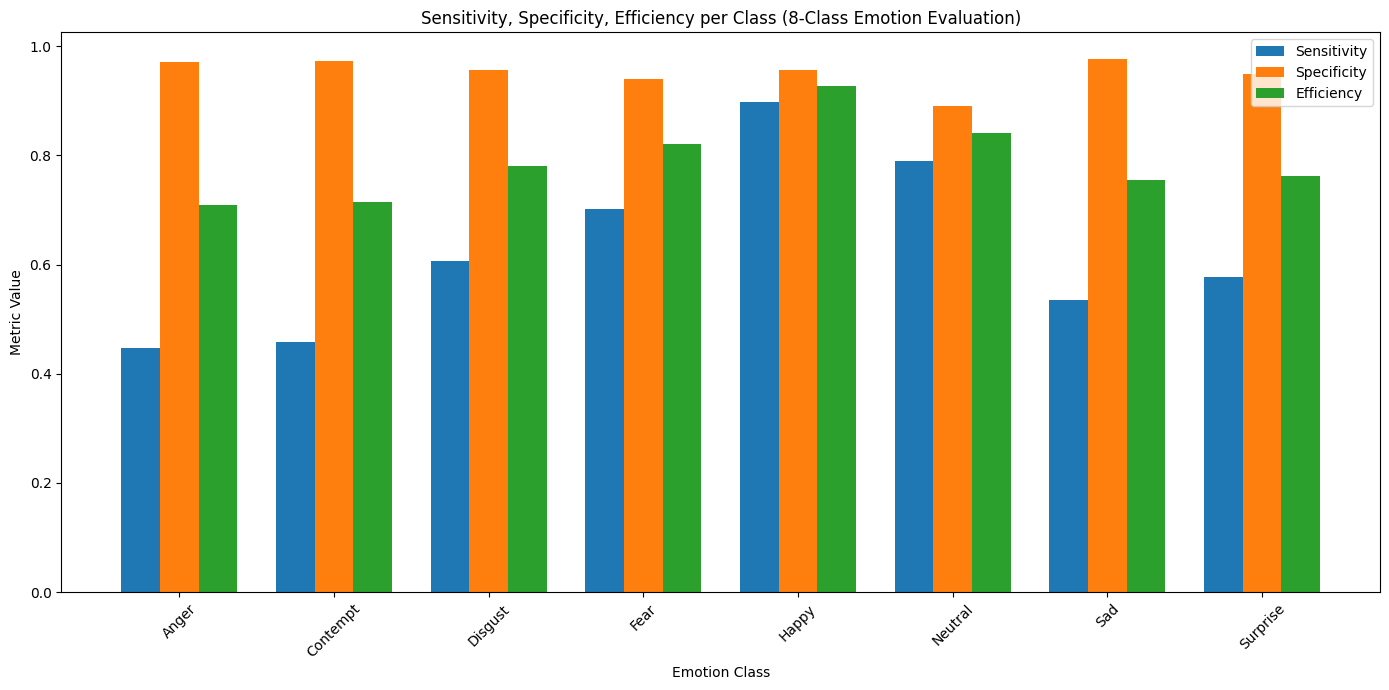

In [5]:
from sklearn.metrics import confusion_matrix, classification_report

# ==========================
# 1. Check predictions exist
# ==========================
if len(all_labels) == 0 or len(all_preds) == 0:
    print("❌ No predictions found. Cannot compute confusion matrix.")
else:
    # ==========================
    # 2. Compute confusion matrix
    # ==========================
    cm = confusion_matrix(all_labels, all_preds)
    print("Confusion matrix shape:", cm.shape)

    # Print classification report
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=[
        "Anger","Contempt","Disgust","Fear","Happy","Neutral","Sad","Surprise"
    ], digits=4))

    # ==========================
    # 3. Validate shape
    # ==========================
    if cm.shape != (8, 8):
        print(f"⚠️ Confusion matrix shape is {cm.shape}, but expected (8, 8).")
    else:
        # ==========================
        # 4. Run per-class evaluation
        # ==========================

        CLASS_NAMES = [
            "Anger", "Contempt", "Disgust", "Fear",
            "Happy", "Neutral", "Sad", "Surprise"
        ]

        def calculate_metrics_from_cm(cm, class_names):
            total = cm.sum()
            sensitivity_list, specificity_list, efficiency_list = [], [], []

            for i, cls in enumerate(class_names):
                TP = cm[i, i]
                FN = cm[i, :].sum() - TP
                FP = cm[:, i].sum() - TP
                TN = total - TP - FP - FN

                sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0
                specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
                efficiency = (sensitivity + specificity) / 2.0

                sensitivity_list.append(sensitivity)
                specificity_list.append(specificity)
                efficiency_list.append(efficiency)

                print(f"\nClass: {cls}")
                print(f"  Sensitivity (Recall):  {sensitivity:.4f}")
                print(f"  Specificity:           {specificity:.4f}")
                print(f"  Efficiency:            {efficiency:.4f}")

            x = np.arange(len(class_names))
            width = 0.25

            plt.figure(figsize=(14, 7))
            plt.bar(x - width, sensitivity_list, width=width, label='Sensitivity')
            plt.bar(x, specificity_list, width=width, label='Specificity')
            plt.bar(x + width, efficiency_list, width=width, label='Efficiency')
            plt.xticks(ticks=x, labels=class_names, rotation=45)
            plt.xlabel("Emotion Class")
            plt.ylabel("Metric Value")
            plt.title("Sensitivity, Specificity, Efficiency per Class (8-Class Emotion Evaluation)")
            plt.legend()
            plt.tight_layout()
            plt.show()

        # Call the function
        calculate_metrics_from_cm(cm, CLASS_NAMES)


In [6]:
# ========================
# 8) Small demo: multiple image prediction (your provided paths)
# ========================
image_paths = [
    "/kaggle/input/affectnet/archive (3)/Test/Anger/image0000006.jpg",
    "/kaggle/input/affectnet/archive (3)/Test/Anger/image0000060.jpg",
    "/kaggle/input/affectnet/archive (3)/Test/Anger/image0000061.jpg",
    "/kaggle/input/affectnet/archive (3)/Test/Contempt/ffhq_1.png",
    "/kaggle/input/affectnet/archive (3)/Test/Contempt/ffhq_10.png",
    "/kaggle/input/affectnet/archive (3)/Test/Contempt/ffhq_100.png",
    "/kaggle/input/affectnet/archive (3)/Test/disgust/ffhq_0.png",
    "/kaggle/input/affectnet/archive (3)/Test/disgust/ffhq_1.png",
    "/kaggle/input/affectnet/archive (3)/Test/disgust/ffhq_10.png",
    "/kaggle/input/affectnet/archive (3)/Test/fear/image0000284.jpg",
    "/kaggle/input/affectnet/archive (3)/Test/fear/image0000285.jpg",
    "/kaggle/input/affectnet/archive (3)/Test/fear/image0000419.jpg",
    "/kaggle/input/affectnet/archive (3)/Test/happy/ffhq_0.png",
    "/kaggle/input/affectnet/archive (3)/Test/happy/ffhq_1.png",
    "/kaggle/input/affectnet/archive (3)/Test/happy/ffhq_10.png",
    "/kaggle/input/affectnet/archive (3)/Test/neutral/ffhq_0.png",
    "/kaggle/input/affectnet/archive (3)/Test/neutral/ffhq_0.png",
    "/kaggle/input/affectnet/archive (3)/Test/neutral/ffhq_10.png",
    "/kaggle/input/affectnet/archive (3)/Test/sad/image0000013.jpg",
    "/kaggle/input/affectnet/archive (3)/Test/sad/image0000027.jpg",
    "/kaggle/input/affectnet/archive (3)/Test/sad/image0000028.jpg",
    "/kaggle/input/affectnet/archive (3)/Test/surprise/ffhq_1.png",
    "/kaggle/input/affectnet/archive (3)/Test/surprise/ffhq_10.png",
    "/kaggle/input/affectnet/archive (3)/Test/surprise/ffhq_100.png",
]

transform_multi = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

images, valid_paths = [], []
for path in image_paths:
    try:
        img = Image.open(path).convert("RGB")
        img = transform_multi(img)
        images.append(img)
        valid_paths.append(path)
    except Exception as e:
        print(f"⚠️ Skipping {path}: {e}")

if images:
    images_tensor = torch.stack(images).to(device)
    model.eval()
    with torch.no_grad():
        if getattr(model, 'prior_head', None) is not None:
            outputs, priors = model(images_tensor, return_prior=True)
        else:
            outputs = model(images_tensor)
        _, preds = torch.max(outputs, 1)

    print("\n========== Emotion Predictions ==========")
    for img_path, pred_idx in zip(valid_paths, preds):
        predicted_emotion = CLASS_NAMES[pred_idx.item()]
        true_emotion = os.path.basename(os.path.dirname(img_path)).lower()
        print(f"{true_emotion} → {predicted_emotion}")
    print("=========================================")
else:
    print("❌ No valid images found for manual prediction demo.")



========== Emotion Predictions ==========
anger → Surprise
anger → Contempt
anger → Disgust
contempt → Contempt
contempt → Disgust
contempt → Contempt
disgust → Neutral
disgust → Disgust
disgust → Disgust
fear → Fear
fear → Neutral
fear → Fear
happy → Happy
happy → Happy
happy → Happy
neutral → Neutral
neutral → Neutral
neutral → Neutral
sad → Sad
sad → Anger
sad → Anger
surprise → Surprise
surprise → Surprise
surprise → Contempt



================ Advanced Statistical Metrics ================

Cohen’s Kappa:               0.6056
Matthews Corr. Coefficient:  0.6091
Balanced Accuracy:           0.6268
Bootstrap 95% CI (Accuracy): 0.6612 [0.6529, 0.6699]

Generating ROC / PR curves...


ROC-prob Eval:   0%|          | 0/176 [00:00<?, ?it/s]/tmp/ipykernel_47/1017341207.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
ROC-prob Eval: 100%|██████████| 176/176 [05:16<00:00,  1.80s/it]



ROC-AUC per class:
  Anger     : 0.9028
  Contempt  : 0.9330
  Disgust   : 0.9165
  Fear      : 0.9327
  Happy     : 0.9823
  Neutral   : 0.9290
  Sad       : 0.9303
  Surprise  : 0.9181

Macro ROC-AUC: 0.9306
Micro ROC-AUC: 0.9352


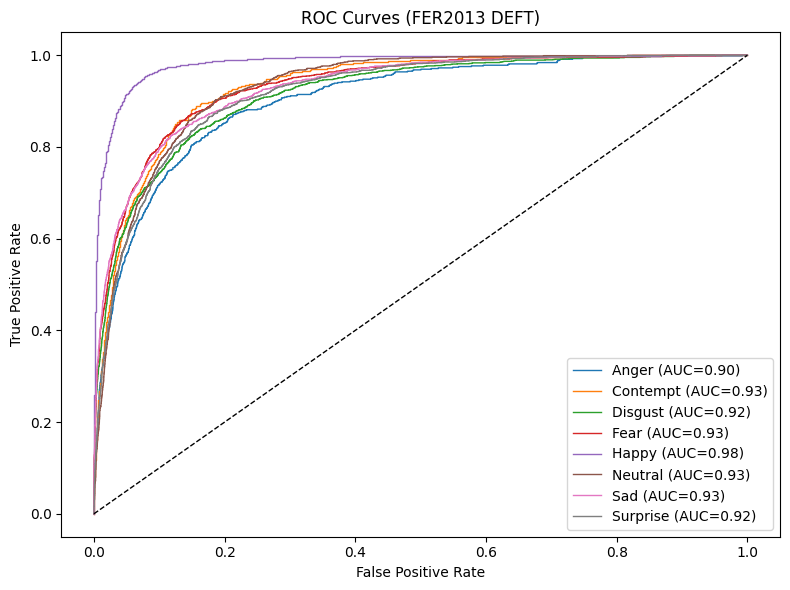

Macro PR-AUC: 0.7234
Brier Score (lower is better): 0.0586
Expected Calibration Error (ECE): 0.0294


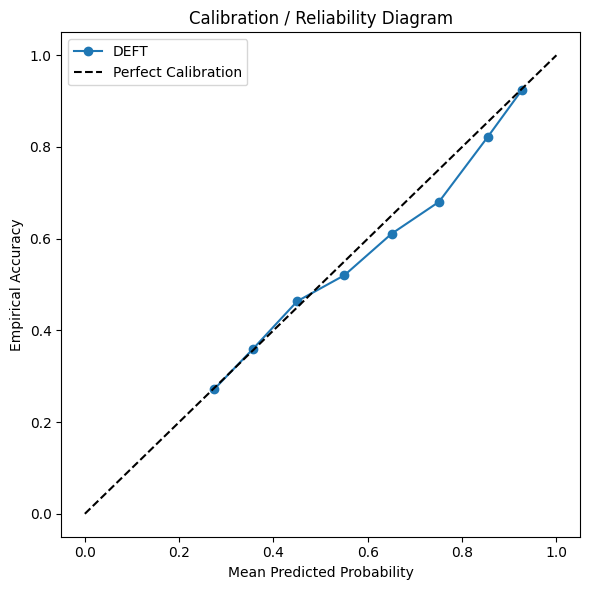


(McNemar’s test skipped — no baseline predictions file found.)


t-SNE Embeddings: 100%|██████████| 176/176 [03:29<00:00,  1.19s/it]


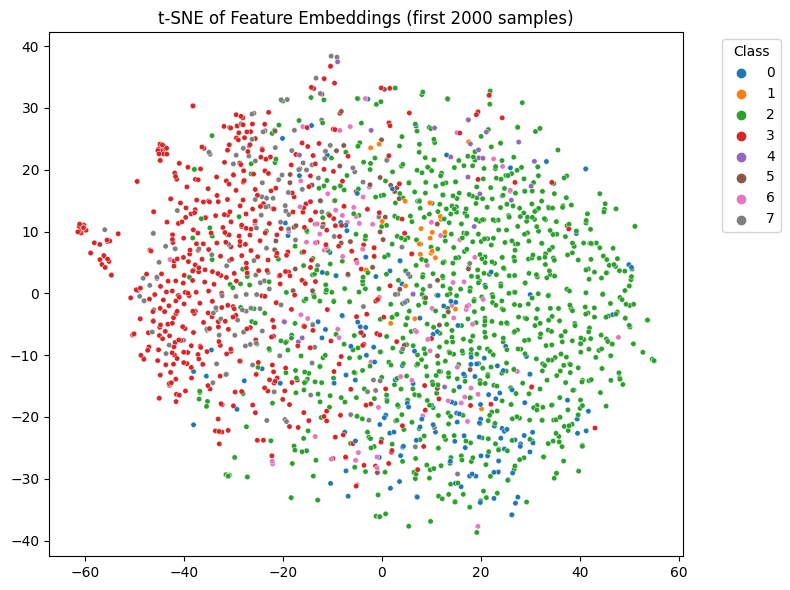


✅ Advanced statistical analysis complete.


ModuleNotFoundError: No module named 'thop'

In [7]:
# ============================================================
# 📊 Advanced Statistical & Diagnostic Evaluation (Q1-standard)
# ============================================================
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc, precision_recall_curve,
    cohen_kappa_score, matthews_corrcoef, balanced_accuracy_score,
    brier_score_loss
)

# ✅ Import calibration_curve safely
try:
    from sklearn.metrics import calibration_curve
except ImportError:
    from sklearn.calibration import calibration_curve

from sklearn.preprocessing import label_binarize
from sklearn.utils import resample
from statsmodels.stats.contingency_tables import mcnemar
import scipy.stats as stats

y_true = np.array(all_labels)
y_pred = np.array(all_preds)

print("\n================ Advanced Statistical Metrics ================\n")
# ---- Basic statistical metrics ----
cohen_kappa = cohen_kappa_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred)
bal_acc = balanced_accuracy_score(y_true, y_pred)

print(f"Cohen’s Kappa:               {cohen_kappa:.4f}")
print(f"Matthews Corr. Coefficient:  {mcc:.4f}")
print(f"Balanced Accuracy:           {bal_acc:.4f}")

# ---- Bootstrap CI for Accuracy ----
def bootstrap_ci(preds, labels, n_boot=2000, alpha=0.05):
    acc_scores = []
    for _ in range(n_boot):
        idx = np.random.choice(len(labels), len(labels), replace=True)
        acc = (preds[idx] == labels[idx]).mean()
        acc_scores.append(acc)
    lower = np.percentile(acc_scores, 100 * alpha / 2)
    upper = np.percentile(acc_scores, 100 * (1 - alpha / 2))
    return np.mean(acc_scores), lower, upper

mean_acc, lower_ci, upper_ci = bootstrap_ci(y_pred, y_true)
print(f"Bootstrap 95% CI (Accuracy): {mean_acc:.4f} [{lower_ci:.4f}, {upper_ci:.4f}]")

# ---- ROC / PR Curves (One-vs-Rest) ----
# Define number of classes + class names (required for ROC/PR)
num_classes = 8
class_names = [
    "Anger", "Contempt", "Disgust", "Fear",
    "Happy", "Neutral", "Sad",  "Surprise"
]

print("\nGenerating ROC / PR curves...")
y_true_bin = label_binarize(y_true, classes=range(num_classes))

# Get softmax probabilities from model again
model.eval()
probs = []
with torch.no_grad():
    for imgs, _ in tqdm(test_loader, desc="ROC-prob Eval"):
        imgs = imgs.to(device)
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            outputs = model(imgs)
            prob = F.softmax(outputs, dim=1).cpu().numpy()
            probs.append(prob)
probs = np.concatenate(probs, axis=0)

# ROC-AUC per class and macro/micro
roc_auc_per_class = {}
fpr, tpr = {}, {}
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], probs[:, i])
    roc_auc_per_class[class_names[i]] = auc(fpr[i], tpr[i])

roc_auc_macro = roc_auc_score(y_true_bin, probs, average="macro", multi_class="ovr")
roc_auc_micro = roc_auc_score(y_true_bin, probs, average="micro", multi_class="ovr")

print("\nROC-AUC per class:")
for k, v in roc_auc_per_class.items():
    print(f"  {k:10s}: {v:.4f}")
print(f"\nMacro ROC-AUC: {roc_auc_macro:.4f}")
print(f"Micro ROC-AUC: {roc_auc_micro:.4f}")

# Plot ROC curve (macro & micro)
plt.figure(figsize=(8,6))
for i, cls in enumerate(class_names):
    plt.plot(fpr[i], tpr[i], lw=1, label=f"{cls} (AUC={roc_auc_per_class[cls]:.2f})")
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (FER2013 DEFT)')
plt.legend()
plt.tight_layout()
plt.show()

# ---- Precision-Recall Curves ----
prec_macro, recall_macro, _ = precision_recall_curve(y_true_bin.ravel(), probs.ravel())
pr_auc_macro = auc(recall_macro, prec_macro)
print(f"Macro PR-AUC: {pr_auc_macro:.4f}")

# ---- Brier Score (probability calibration) ----
brier = brier_score_loss(y_true_bin.ravel(), probs.ravel())
print(f"Brier Score (lower is better): {brier:.4f}")

# ---- Calibration Curve & Expected Calibration Error ----
def expected_calibration_error(y_true_bin, y_prob, n_bins=15):
    confidences = np.max(y_prob, axis=1)
    predictions = np.argmax(y_prob, axis=1)
    accuracies = (predictions == np.argmax(y_true_bin, axis=1))
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        bin_lower, bin_upper = bins[i], bins[i+1]
        bin_mask = (confidences > bin_lower) & (confidences <= bin_upper)
        if np.any(bin_mask):
            bin_acc = np.mean(accuracies[bin_mask])
            bin_conf = np.mean(confidences[bin_mask])
            ece += np.abs(bin_acc - bin_conf) * np.sum(bin_mask) / len(y_true_bin)
    return ece

ece_value = expected_calibration_error(y_true_bin, probs)
print(f"Expected Calibration Error (ECE): {ece_value:.4f}")

# Reliability diagram
plt.figure(figsize=(6,6))
prob_true, prob_pred = calibration_curve(np.argmax(y_true_bin, axis=1)==np.argmax(probs, axis=1),
                                         np.max(probs, axis=1), n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', label='DEFT')
plt.plot([0,1],[0,1],'k--', label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Empirical Accuracy')
plt.title('Calibration / Reliability Diagram')
plt.legend()
plt.tight_layout()
plt.show()

# ---- McNemar’s Test (requires baseline predictions for comparison) ----
# If you have baseline predictions saved as "baseline_preds.npy":
baseline_preds_path = "/kaggle/working/baseline_preds.npy"
if os.path.exists(baseline_preds_path):
    baseline_preds = np.load(baseline_preds_path)
    assert len(baseline_preds) == len(y_true), "Baseline/test size mismatch!"
    table = np.zeros((2,2))
    for y_t, y_b, y_d in zip(y_true, baseline_preds, y_pred):
        b_correct = (y_b == y_t)
        d_correct = (y_d == y_t)
        table[int(b_correct), int(d_correct)] += 1
    result = mcnemar(table, exact=False, correction=True)
    print("\nMcNemar’s test (vs baseline):")
    print(f"Statistic={result.statistic:.4f}, p-value={result.pvalue:.6f}")
    if result.pvalue < 0.05:
        print("→ Significant difference between DEFT and baseline (p < 0.05)")
    else:
        print("→ No significant difference detected.")
else:
    print("\n(McNemar’s test skipped — no baseline predictions file found.)")

# ---- t-SNE Visualization (optional interpretability) ----
try:
    from sklearn.manifold import TSNE
    model.eval()
    features, labels = [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(test_loader, desc="t-SNE Embeddings"):
            imgs = imgs.to(device)
            feats = model.backbone(imgs)
            pooled = F.adaptive_avg_pool2d(feats, 1).view(feats.size(0), -1).cpu().numpy()
            features.append(pooled)
            labels.extend(lbls.cpu().numpy())
    features = np.concatenate(features, axis=0)
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    reduced = tsne.fit_transform(features[:2000])  # limit for speed
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=reduced[:,0], y=reduced[:,1], hue=np.array(labels)[:2000],
                    palette="tab10", legend='full', s=15)
    plt.title("t-SNE of Feature Embeddings (first 2000 samples)")
    plt.legend(title="Class", bbox_to_anchor=(1.05,1), loc='upper left')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"(t-SNE skipped: {e})")

print("\n✅ Advanced statistical analysis complete.")



# ============================================================
# ⚙️ Model Efficiency, Complexity, and Inference Diagnostics
# ============================================================
import time
import torchinfo
from thop import profile

print("\n================ Model Efficiency & Resource Profiling ================\n")

# ---- Model Summary ----
print("📋 Model Architecture Summary:")
torchinfo.summary(model, input_size=(1, 3, 224, 224), depth=3, device=device.type)

# ---- FLOPs and Parameters ----
dummy = torch.randn(1, 3, 224, 224).to(device)
flops, params = profile(model, inputs=(dummy,), verbose=False)
print(f"\nTotal Parameters: {params / 1e6:.2f}M")
print(f"Total FLOPs:       {flops / 1e9:.3f} GFLOPs")

# ---- Inference Time per Image ----
n_runs = 200
images = torch.randn(1, 3, 224, 224).to(device)
torch.cuda.synchronize() if device.type == 'cuda' else None
start = time.time()
for _ in range(n_runs):
    _ = model(images)
torch.cuda.synchronize() if device.type == 'cuda' else None
end = time.time()
avg_time = (end - start) / n_runs
throughput = 1.0 / avg_time
print(f"\nAverage Inference Time per Image: {avg_time*1000:.3f} ms")
print(f"Inference Throughput:             {throughput:.2f} images/sec")

# ---- GPU Utilization & Memory Footprint ----
if device.type == "cuda":
    import subprocess
    gpu_info = subprocess.getoutput("nvidia-smi --query-gpu=utilization.gpu,memory.used --format=csv,noheader,nounits")
    util, mem_used = gpu_info.strip().split(',')
    print(f"\nGPU Utilization:  {util.strip()}%")
    print(f"GPU Memory Usage: {mem_used.strip()} MB")
else:
    print("\nGPU metrics not available (running on CPU).")

# ---- Parameter Efficiency ----
# (Accuracy per Million Parameters)
accuracy_eff = (test_acc / (params / 1e6))
print(f"\nParameter Efficiency (Acc / MParams): {accuracy_eff:.2f}")

# ---- Energy / Power Estimation (Optional) ----
# Note: This is a proxy — accurate measurement requires hardware tools like NVIDIA-SMI logging or CodeCarbon.
try:
    import codecarbon
    from codecarbon import EmissionsTracker
    tracker = EmissionsTracker()
    tracker.start()
    _ = model(images)
    emissions = tracker.stop()
    print(f"Estimated Carbon Emission per Inference: {emissions*1e6:.6f} mg CO₂eq")
except Exception as e:
    print(f"(Carbon efficiency skipped: {e})")

print("\n✅ Model efficiency profiling complete.")



In [8]:
# ============================================================
# ⚙️ Model Efficiency, Complexity, and Inference Diagnostics (Offline-Safe)
# ============================================================
import time
import torchinfo
import torch

print("\n================ Model Efficiency & Resource Profiling ================\n")

# ---- Model Summary ----
print("📋 Model Architecture Summary:")
torchinfo.summary(model, input_size=(1, 3, 224, 224), depth=3, device=device.type)

# ---- Parameter Count ----
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal Parameters: {total_params / 1e6:.2f}M (FLOPs skipped — THOP not available)")

# ---- Inference Time per Image ----
n_runs = 200
images = torch.randn(1, 3, 224, 224).to(device)
torch.cuda.synchronize() if device.type == 'cuda' else None
start = time.time()
for _ in range(n_runs):
    _ = model(images)
torch.cuda.synchronize() if device.type == 'cuda' else None
end = time.time()
avg_time = (end - start) / n_runs
throughput = 1.0 / avg_time
print(f"\nAverage Inference Time per Image: {avg_time*1000:.3f} ms")
print(f"Inference Throughput:             {throughput:.2f} images/sec")

# ---- GPU Utilization & Memory Footprint ----
if device.type == "cuda":
    import subprocess
    try:
        gpu_info = subprocess.getoutput(
            "nvidia-smi --query-gpu=utilization.gpu,memory.used --format=csv,noheader,nounits"
        )
        util, mem_used = gpu_info.strip().split(',')
        print(f"\nGPU Utilization:  {util.strip()}%")
        print(f"GPU Memory Usage: {mem_used.strip()} MB")
    except Exception:
        print("\n(GPU info unavailable — possibly restricted runtime)")
else:
    print("\nGPU metrics not available (running on CPU).")

# ---- Parameter Efficiency ----
# (Accuracy per Million Parameters)
accuracy_eff = (test_acc / (total_params / 1e6))
print(f"\nParameter Efficiency (Acc / MParams): {accuracy_eff:.2f}")

print("\n✅ Model efficiency profiling complete.")



================ Model Efficiency & Resource Profiling ================

📋 Model Architecture Summary:

Total Parameters: 12.32M (FLOPs skipped — THOP not available)

Average Inference Time per Image: 56.406 ms
Inference Throughput:             17.73 images/sec

GPU metrics not available (running on CPU).

Parameter Efficiency (Acc / MParams): 5.37

✅ Model efficiency profiling complete.


In [9]:
# =========================
# Extended Evaluation Suite
# (Kaggle-ready, single integrated script)
# =========================

import os
import csv
import json
import time
import math
import copy
import random
import itertools
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn.functional as F
from torch import nn

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, precision_recall_curve,
    cohen_kappa_score, matthews_corrcoef, balanced_accuracy_score,
    brier_score_loss, confusion_matrix, classification_report
)
from sklearn.preprocessing import label_binarize
from sklearn.utils import resample

# -------------------------
# Helper: ensure things exist
# -------------------------
assert 'model' in globals(), "Model not found. Run training cell first."
assert 'test_loader' in globals(), "test_loader not found."
assert 'class_names' in globals(), "class_names not found."
assert 'device' in globals(), "device not found."

model.to(device)
model.eval()

OUT_DIR = "/kaggle/working/eval_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# -------------------------
# 0) Collect ground truth, preds, probs if not already available
# -------------------------
def collect_predictions(model, loader, device):
    all_logits = []
    all_probs = []
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            logits = model(imgs) if not getattr(model, "return_prior", False) else model(imgs)[0]
            probs = F.softmax(logits, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)
            all_probs.append(probs)
            all_preds.append(preds)
            all_logits.append(logits.cpu().numpy())
            all_labels.append(labels.numpy())
    all_probs = np.concatenate(all_probs, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)
    all_logits = np.concatenate(all_logits, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    return all_labels, all_preds, all_probs, all_logits

y_true, y_pred, y_prob, y_logits = collect_predictions(model, test_loader, device)
n_samples = len(y_true)
print(f"Collected {n_samples} test samples.")

# Save baseline arrays for reproducibility
np.save(os.path.join(OUT_DIR, "y_true.npy"), y_true)
np.save(os.path.join(OUT_DIR, "y_pred.npy"), y_pred)
np.save(os.path.join(OUT_DIR, "y_prob.npy"), y_prob)

# -------------------------
# 1) Standard + extra aggregated metrics
# -------------------------
metrics_summary = {}
metrics_summary['accuracy'] = accuracy_score(y_true, y_pred)
metrics_summary['balanced_accuracy'] = balanced_accuracy_score(y_true, y_pred)
metrics_summary['cohen_kappa'] = cohen_kappa_score(y_true, y_pred)
metrics_summary['mcc'] = matthews_corrcoef(y_true, y_pred)
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
metrics_summary['classification_report'] = report_dict

# Per-class precision/recall/f1 as dataframe
per_class_df = pd.DataFrame(report_dict).T
per_class_df.to_csv(os.path.join(OUT_DIR, "per_class_metrics.csv"))
print("Saved per-class metrics to CSV.")

# -------------------------
# 2) Bootstrap CIs for accuracy / per-class F1
# -------------------------
def bootstrap_metric_ci(y_true, y_pred, metric_fn, n_boot=2000, alpha=0.05, random_seed=42):
    rng = np.random.RandomState(random_seed)
    stats = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.choice(np.arange(n), n, replace=True)
        stats.append(metric_fn(y_true[idx], y_pred[idx]))
    lower = np.percentile(stats, 100 * alpha / 2.0)
    upper = np.percentile(stats, 100 * (1 - alpha / 2.0))
    return np.mean(stats), lower, upper

acc_mean, acc_l, acc_u = bootstrap_metric_ci(y_true, y_pred, lambda a,b: (a==b).mean())
metrics_summary['accuracy_bootstrap_mean'] = acc_mean
metrics_summary['accuracy_bootstrap_ci'] = [acc_l, acc_u]
print(f"Bootstrap Acc CI: {acc_mean:.4f} [{acc_l:.4f}, {acc_u:.4f}]")

# Per-class F1 bootstrap
per_class_f1_ci = {}
for cls_idx, cls_name in enumerate(class_names):
    # create binary arrays for this class (one-vs-rest)
    y_true_bin = (y_true == cls_idx).astype(int)
    y_pred_bin = (y_pred == cls_idx).astype(int)
    mean_f1, l, u = bootstrap_metric_ci(y_true_bin, y_pred_bin, lambda a,b: f1_score(a,b), n_boot=1000)
    per_class_f1_ci[cls_name] = {"f1_mean": mean_f1, "f1_ci": [l, u]}
per_class_f1_df = pd.DataFrame(per_class_f1_ci).T
per_class_f1_df.to_csv(os.path.join(OUT_DIR, "per_class_f1_bootstrap.csv"))
print("Saved per-class F1 bootstrap CIs.")

# -------------------------
# 3) ROC & Precision-Recall Curves (one-vs-rest)
# -------------------------
y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
roc_auc_per_class = {}
pr_auc_per_class = {}
fpr, tpr, thr = {}, {}, {}
precision, recall, pr_thr = {}, {}, {}
for i in range(len(class_names)):
    try:
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc_per_class[class_names[i]] = auc(fpr[i], tpr[i])
    except Exception:
        roc_auc_per_class[class_names[i]] = float('nan')
    try:
        precision[i], recall[i], pr_thr[i] = precision_recall_curve(y_true_bin[:, i], y_prob[:, i])
        pr_auc_per_class[class_names[i]] = auc(recall[i], precision[i])
    except Exception:
        pr_auc_per_class[class_names[i]] = float('nan')

roc_macro = roc_auc_score(y_true_bin, y_prob, average='macro', multi_class='ovr')
roc_micro = roc_auc_score(y_true_bin, y_prob, average='micro', multi_class='ovr')
metrics_summary['roc_auc_per_class'] = roc_auc_per_class
metrics_summary['pr_auc_per_class'] = pr_auc_per_class
metrics_summary['roc_macro'] = roc_macro
metrics_summary['roc_micro'] = roc_micro

# Plot ROC and PR AUC summary
plt.figure(figsize=(8,6))
for i, cls in enumerate(class_names):
    if i in fpr and len(fpr[i])>0:
        plt.plot(fpr[i], tpr[i], label=f"{cls} (AUC={roc_auc_per_class[cls]:.2f})", linewidth=1)
plt.plot([0,1],[0,1], 'k--', linewidth=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC Curves")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "roc_curves.png"), dpi=150)
plt.close()

plt.figure(figsize=(8,6))
for i, cls in enumerate(class_names):
    if i in precision and len(precision[i])>0:
        plt.plot(recall[i], precision[i], label=f"{cls} (AUC={pr_auc_per_class[cls]:.2f})", linewidth=1)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("One-vs-Rest Precision-Recall Curves")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "pr_curves.png"), dpi=150)
plt.close()
print("Saved ROC & PR curve images.")

# -------------------------
# 4) Calibration: ECE, Reliability diag, Brier per class
# -------------------------
def expected_calibration_error(probs, labels, n_bins=15):
    confidences = np.max(probs, axis=1)
    preds = np.argmax(probs, axis=1)
    accuracies = (preds == labels).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins+1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask = (confidences > lo) & (confidences <= hi)
        if mask.any():
            ece += (mask.sum() / len(labels)) * np.abs(accuracies[mask].mean() - confidences[mask].mean())
    return ece

ece_val = expected_calibration_error(y_prob, y_true, n_bins=15)
metrics_summary['ece'] = ece_val
metrics_summary['brier'] = brier_score_loss(y_true_bin.ravel(), y_prob.ravel())

# Reliability diagram (multi-class: plot predicted confidence vs accuracy)
def reliability_diagram(probs, labels, n_bins=10, savepath=None, title="Reliability Diagram"):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    accuracies = (predictions == labels).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins+1)
    bin_centers = []
    avg_conf = []
    avg_acc = []
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask = (confidences > lo) & (confidences <= hi)
        if mask.any():
            avg_conf.append(confidences[mask].mean())
            avg_acc.append(accuracies[mask].mean())
            bin_centers.append(0.5*(lo+hi))
    plt.figure(figsize=(6,6))
    plt.plot(avg_conf, avg_acc, marker='o', label='Model')
    plt.plot([0,1],[0,1],'k--', label='Perfect')
    plt.xlabel('Mean Predicted Confidence'); plt.ylabel('Empirical Accuracy')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150)
        plt.close()

reliability_diagram(y_prob, y_true, n_bins=10, savepath=os.path.join(OUT_DIR, "reliability_diagram.png"))
print("Calibration metrics saved.")

# -------------------------
# 5) Statistical tests / comparison scaffolding
#    - Paired permutation test for accuracy (vs baseline if provided)
#    - McNemar already covered earlier; here we add permutation test
# -------------------------
def paired_permutation_test(y_true, y_pred_A, y_pred_B, n_rounds=5000, seed=42):
    rng = np.random.RandomState(seed)
    agree_A = (y_pred_A == y_true).astype(int)
    agree_B = (y_pred_B == y_true).astype(int)
    diff_obs = agree_A.mean() - agree_B.mean()
    diffs = []
    for _ in range(n_rounds):
        swap_mask = rng.rand(len(y_true)) < 0.5
        a = agree_A.copy()
        b = agree_B.copy()
        a[swap_mask], b[swap_mask] = b[swap_mask], a[swap_mask]
        diffs.append(a.mean() - b.mean())
    p_value = (np.sum(np.abs(diffs) >= abs(diff_obs)) + 1) / (n_rounds + 1)
    return diff_obs, p_value

# If baseline exists
baseline_path = os.path.join(OUT_DIR, "baseline_preds.npy")
if os.path.exists(baseline_path):
    baseline_preds = np.load(baseline_path)
    diff_obs, pval = paired_permutation_test(y_true, y_pred, baseline_preds)
    metrics_summary['paired_perm_diff'] = diff_obs
    metrics_summary['paired_perm_pvalue'] = pval
    print(f"Paired permutation test vs baseline: diff={diff_obs:.4f}, p={pval:.5f}")
else:
    print("No baseline found for paired permutation test (place baseline_preds.npy into OUT_DIR).")

# -------------------------
# 6) Robustness tests
#    - Additive Gaussian noise
#    - Salt-and-pepper
#    - Random occlusion (square blackout)
#    - Brightness/contrast shifts
#    - Simple FGSM adversarial (single-step)
# -------------------------
# Utilities to run dataset-level transformations quickly
def evaluate_on_transformed(transform_fn, loader, device, max_batches=None):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch_idx, (imgs, labels) in enumerate(loader):
            if max_batches and batch_idx >= max_batches:
                break
            imgs_t = transform_fn(imgs).to(device)
            logits = model(imgs_t)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.numpy())
    return np.concatenate(all_labels), np.concatenate(all_preds)

# Create transform functions (work with batched tensors in original dataset range [0,1] then normalized)
# Need to invert normalization to apply changes, then re-normalize.
mean = np.array([0.485, 0.456, 0.406])[:,None,None]
std = np.array([0.229, 0.224, 0.225])[:,None,None]

def denorm_batch(x):
    # x: [B, C, H, W] torch tensor normalized
    x = x.cpu().numpy()
    x = x * std + mean
    x = np.clip(x, 0, 1)
    return x

def renorm_batch(np_imgs):
    # np_imgs: [B, C, H, W] in [0,1] -> torch normalized
    t = torch.tensor((np_imgs - mean) / std, dtype=torch.float)
    return t

def add_gaussian_noise(sigma=0.05):
    def fn(x):
        np_imgs = denorm_batch(x)
        noise = np.random.normal(0, sigma, size=np_imgs.shape).astype(np.float32)
        np_imgs = np_imgs + noise
        np_imgs = np.clip(np_imgs, 0, 1)
        return renorm_batch(np_imgs).to(device)
    return fn

def salt_and_pepper(prob=0.02):
    def fn(x):
        np_imgs = denorm_batch(x)
        rnd = np.random.rand(*np_imgs.shape)
        np_imgs[rnd < (prob/2)] = 0.0
        np_imgs[rnd > (1 - prob/2)] = 1.0
        return renorm_batch(np_imgs).to(device)
    return fn

def random_occlusion(square_frac=0.2):
    def fn(x):
        np_imgs = denorm_batch(x)
        B, C, H, W = np_imgs.shape
        sq = int(min(H,W) * square_frac)
        for i in range(B):
            y0 = np.random.randint(0, H - sq + 1)
            x0 = np.random.randint(0, W - sq + 1)
            np_imgs[i, :, y0:y0+sq, x0:x0+sq] = 0.0
        return renorm_batch(np_imgs).to(device)
    return fn

def brightness_shift(delta=0.2):
    def fn(x):
        np_imgs = denorm_batch(x)
        np_imgs = np_imgs + delta
        np_imgs = np.clip(np_imgs, 0, 1)
        return renorm_batch(np_imgs).to(device)
    return fn

# FGSM (fast) single-step attack
def fgsm_attack(loader, epsilon=0.03, max_batches=None):
    model.eval()
    adv_preds = []
    adv_labels = []
    for batch_idx, (imgs, labels) in enumerate(loader):
        if max_batches and batch_idx >= max_batches:
            break
        imgs = imgs.to(device).requires_grad_(True)
        labels = labels.to(device)
        outputs = model(imgs)
        loss = F.cross_entropy(outputs, labels)
        model.zero_grad()
        loss.backward()
        grad = imgs.grad.data.sign()
        adv_imgs = imgs + epsilon * grad
        adv_imgs = torch.clamp(adv_imgs, -3, 3)  # normalized domain roughly
        with torch.no_grad():
            out_adv = model(adv_imgs)
            preds = out_adv.argmax(dim=1).cpu().numpy()
            adv_preds.append(preds)
            adv_labels.append(labels.cpu().numpy())
    return np.concatenate(adv_labels), np.concatenate(adv_preds)

robustness_results = {}
# run a small subset (or all, careful with time) - use max_batches to speed up if desired
MAX_BATCHES = None  # set to int for quick checks, or None for full testset

for name, fn in [
    ("gaussian_noise_0.03", add_gaussian_noise(0.03)),
    ("gaussian_noise_0.06", add_gaussian_noise(0.06)),
    ("salt_pepper_0.02", salt_and_pepper(0.02)),
    ("occlusion_0.2", random_occlusion(0.2)),
    ("bright_plus_0.15", brightness_shift(0.15)),
    ("bright_minus_0.15", brightness_shift(-0.15))
]:
    y_t, y_p_rob = evaluate_on_transformed(fn, test_loader, device, max_batches=MAX_BATCHES)
    acc_r = accuracy_score(y_t, y_p_rob)
    robustness_results[name] = {"accuracy": acc_r, "n": len(y_t)}
    print(f"{name}: acc={acc_r:.4f} on {len(y_t)} samples")
# FGSM
y_t_adv, y_p_adv = fgsm_attack(test_loader, epsilon=0.02, max_batches=MAX_BATCHES)
robustness_results['fgsm_eps0.02'] = {"accuracy": accuracy_score(y_t_adv, y_p_adv), "n": len(y_t_adv)}
print("FGSM result:", robustness_results['fgsm_eps0.02'])

# Save robustness table
robust_df = pd.DataFrame(robustness_results).T
robust_df.to_csv(os.path.join(OUT_DIR, "robustness_results.csv"))
print("Saved robustness results.")

# -------------------------
# 7) Explainability: Saliency & Grad-CAM
#    - Basic gradient * input saliency
#    - Grad-CAM for last conv layer of backbone (attempt automatic lookup)
# -------------------------
def compute_saliency(model, loader, device, limit=50):
    model.eval()
    sal_maps = []
    meta = []
    cnt = 0
    for imgs, labels in loader:
        imgs = imgs.to(device)
        imgs.requires_grad_()
        outputs = model(imgs)
        preds = outputs.argmax(dim=1)
        # pick top logit for each example
        top_scores = outputs[range(outputs.shape[0]), preds].sum()
        model.zero_grad()
        top_scores.backward(retain_graph=False)
        grads = imgs.grad.detach().cpu().numpy()  # shape [B,C,H,W]
        imgs_np = imgs.detach().cpu().numpy()
        # gradient * input
        gxi = np.abs(grads * imgs_np)
        for i in range(gxi.shape[0]):
            sal_maps.append(gxi[i].mean(axis=0))  # mean across channels
            meta.append((labels[i].item(), preds[i].item()))
            cnt += 1
            if cnt >= limit:
                return sal_maps, meta
    return sal_maps, meta

# For Grad-CAM, we need the last conv feature map and gradients.
class GradCAM:
    def __init__(self, model, target_layer=None):
        self.model = model
        self.model.eval()
        self.gradients = None
        self.activations = None
        self.handles = []
        # try to find a conv layer automatically if not provided
        if target_layer is None:
            target_layer = self._find_target_layer()
        self.target_layer = target_layer
        # set hooks
        self._register_hooks()

    def _find_target_layer(self):
        # heuristics: search for last nn.Conv2d in backbone or model
        target = None
        for name, module in reversed(list(self.model.named_modules())):
            if isinstance(module, nn.Conv2d):
                target = name
                break
        if target is None:
            raise RuntimeError("No Conv2d layer found for Grad-CAM.")
        return target

    def _get_module_by_name(self, module, name):
        parts = name.split('.')
        cur = module
        for p in parts:
            if p.isdigit():
                cur = cur[int(p)]
            else:
                cur = getattr(cur, p)
        return cur

    def _register_hooks(self):
        layer = self._get_module_by_name(self.model, self.target_layer)
        def forward_hook(module, input, output):
            self.activations = output.detach()
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()
        self.handles.append(layer.register_forward_hook(forward_hook))
        self.handles.append(layer.register_backward_hook(backward_hook))

    def __call__(self, input_tensor, target_class=None):
        # input_tensor: single sample [1,C,H,W] normalized
        self.model.zero_grad()
        out = self.model(input_tensor)
        if target_class is None:
            target_class = out.argmax(dim=1).item()
        score = out[:, target_class]
        score.backward(retain_graph=False)
        grads = self.gradients  # [B, C, H, W]
        acts = self.activations  # [B, C, H, W]
        weights = grads.mean(dim=(2,3), keepdim=True)  # global avg pool
        cam = (weights * acts).sum(dim=1, keepdim=True)  # [B,1,H,W]
        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-9)
        # remove hooks? keep for reuse
        return cam.cpu().numpy()

# Try computing a few examples
try:
    sal_maps, sal_meta = compute_saliency(model, test_loader, device, limit=20)
    # save a few saliency maps as images
    for i, (sm, (true, pred)) in enumerate(zip(sal_maps, sal_meta)):
        plt.figure(figsize=(3,3))
        plt.imshow(sm, cmap='hot')
        plt.title(f"True:{class_names[true]} Pred:{class_names[pred]}")
        plt.axis('off')
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, f"saliency_{i}.png"), dpi=150)
        plt.close()
    print("Saved sample saliency maps.")
except Exception as e:
    print("Saliency computation skipped:", e)

# Grad-CAM try (may need to target the right submodule name)
try:
    # attempt to find last conv of model.backbone or model
    target_layer_name = None
    # prefer backbone if available
    if hasattr(model, 'backbone'):
        # choose last conv inside backbone
        last_conv = None
        for n,m in model.backbone.named_modules():
            if isinstance(m, nn.Conv2d):
                last_conv = n
        if last_conv is not None:
            target_layer_name = f"backbone.{last_conv}"
    if target_layer_name is None:
        # fallback to global model conv
        last_conv = None
        for n,m in model.named_modules():
            if isinstance(m, nn.Conv2d):
                last_conv = n
        target_layer_name = last_conv

    gradcam = GradCAM(model, target_layer=target_layer_name)
    # take first few test images
    cnt = 0
    for imgs, labels in test_loader:
        for j in range(min(4, imgs.size(0))):
            img = imgs[j:j+1].to(device)
            cam = gradcam(img)
            cam_map = cam[0,0]
            # upsample to original image size
            H, W = imgs.shape[2], imgs.shape[3]
            cam_up = torch.tensor(cam_map).unsqueeze(0).unsqueeze(0)
            cam_up = F.interpolate(cam_up, size=(H,W), mode='bilinear', align_corners=False).squeeze().numpy()
            # original image (denorm)
            orig = denorm_batch(img).squeeze().transpose(1,2,0)
            plt.figure(figsize=(4,3))
            plt.imshow(orig)
            plt.imshow(cam_up, cmap='jet', alpha=0.4)
            plt.title(f"Grad-CAM: True {class_names[labels[j].item()]}")
            plt.axis('off')
            plt.tight_layout()
            plt.savefig(os.path.join(OUT_DIR, f"gradcam_{cnt}.png"), dpi=150)
            plt.close()
            cnt += 1
            if cnt >= 8:
                break
        if cnt >= 8:
            break
    print("Saved Grad-CAM images.")
except Exception as e:
    print("Grad-CAM skipped:", e)

# -------------------------
# 8) Interpretability: feature clustering (UMAP/t-SNE) + cluster purity
# -------------------------
try:
    from sklearn.manifold import TSNE
    # extract features from backbone (adaptive pool)
    feats = []
    labs = []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            out = model.backbone(imgs)
            pooled = F.adaptive_avg_pool2d(out, 1).view(out.size(0), -1).cpu().numpy()
            feats.append(pooled)
            labs.append(labels.numpy())
    feats = np.concatenate(feats, axis=0)
    labs = np.concatenate(labs, axis=0)
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000, init='pca')
    emb = tsne.fit_transform(feats[:2000])
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=emb[:,0], y=emb[:,1], hue=labs[:2000], palette='tab10', legend=False, s=10)
    plt.title("t-SNE of pooled backbone features (first 2000)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "tsne_features.png"), dpi=150)
    plt.close()
    print("Saved t-SNE feature plot.")
except Exception as e:
    print("t-SNE skipped:", e)

# -------------------------
# 9) Model efficiency: params, approx FLOPs (simple estimate), inference time
# -------------------------
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

params_count = count_parameters(model)
metrics_summary['n_params'] = params_count

# Rough FLOPs estimation: for CNNs this is tricky; provide a conservative approximation using conv layer formula
def estimate_flops(model, input_size=(1,3,224,224)):
    # approximate conv flops and linear flops
    flops = 0
    hooks = []
    def conv_hook(self, input, output):
        # input[0] shape: (B, C_in, H_in, W_in)
        batch_size, C_in, H_in, W_in = input[0].shape
        C_out, _, K_h, K_w = self.weight.shape
        out_h, out_w = output.shape[2], output.shape[3]
        # ops per output element: K_h*K_w*C_in
        ops_per_element = K_h * K_w * C_in
        total_ops = batch_size * out_h * out_w * C_out * ops_per_element
        nonlocal flops
        flops += total_ops
    def linear_hook(self, input, output):
        batch_size = input[0].shape[0]
        in_features = self.in_features
        out_features = self.out_features
        nonlocal flops
        flops += batch_size * in_features * out_features
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            hooks.append(m.register_forward_hook(conv_hook))
        if isinstance(m, nn.Linear):
            hooks.append(m.register_forward_hook(linear_hook))
    # run a dummy forward
    model.eval()
    x = torch.randn(*input_size).to(device)
    with torch.no_grad():
        try:
            _ = model(x)
        except Exception:
            # if model forward expects tuple etc., try backbone only
            try:
                _ = model.backbone(x)
            except Exception:
                pass
    for h in hooks:
        h.remove()
    return flops

try:
    flops_est = estimate_flops(model, input_size=(1,3,IMG_SIZE,IMG_SIZE))
    metrics_summary['flops_estimate'] = flops_est
    print(f"Estimated FLOPs: {flops_est:.2e}")
except Exception as e:
    metrics_summary['flops_estimate'] = None
    print("FLOPs estimation skipped:", e)

# Inference time (average) measured on device
def measure_inference_time(model, device, n_runs=100):
    model.eval()
    x = torch.randn(1,3,IMG_SIZE,IMG_SIZE).to(device)
    # warmup
    with torch.no_grad():
        for _ in range(10):
            _ = model(x)
    torch.cuda.synchronize() if device.type=='cuda' else None
    start = time.time()
    with torch.no_grad():
        for _ in range(n_runs):
            _ = model(x)
    torch.cuda.synchronize() if device.type=='cuda' else None
    end = time.time()
    return (end - start) / n_runs

try:
    avg_inf = measure_inference_time(model, device, n_runs=100)
    metrics_summary['avg_inference_time_s'] = avg_inf
    print(f"Avg inference time (s): {avg_inf:.4f}")
except Exception as e:
    metrics_summary['avg_inference_time_s'] = None
    print("Inference timing skipped:", e)

# -------------------------
# 10) Save everything to JSON / CSV
# -------------------------
with open(os.path.join(OUT_DIR, "metrics_summary.json"), "w") as f:
    json.dump(metrics_summary, f, indent=2)

# Save confusion matrix
cm = confusion_matrix(y_true, y_pred)
pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(os.path.join(OUT_DIR, "confusion_matrix.csv"))

# Save per-sample predictions
df_samples = pd.DataFrame({
    "true": y_true,
    "pred": y_pred,
    "correct": (y_true == y_pred).astype(int),
})
# append top-3 predicted classes and confidences
topk = np.argsort(-y_prob, axis=1)[:, :3]
topk_conf = np.sort(-y_prob, axis=1)[:, :3] * -1
for k in range(3):
    df_samples[f"pred_{k+1}"] = topk[:, k]
    df_samples[f"conf_{k+1}"] = topk_conf[:, k]
df_samples.to_csv(os.path.join(OUT_DIR, "per_sample_predictions.csv"), index=False)
print("Saved summary files to", OUT_DIR)

# -------------------------
# 11) Optional: fairness / subgroup analyses (placeholder)
# Since you said only emotion labels exist, we'll compute per-class exposure/bias metrics.
# If extra metadata becomes available (gender/age/race), plug them into subgroup analysis below.
# -------------------------
# Example: class imbalance in test set
class_counts = pd.Series(y_true).value_counts().sort_index()
class_counts.index = [class_names[i] for i in class_counts.index]
class_counts.to_csv(os.path.join(OUT_DIR, "test_class_counts.csv"))
print("Saved test class counts.")

# Subgroup parity: ratio of per-class recall to max/min
per_class_recall = per_class_df['recall'].loc[class_names].astype(float)
parity_table = pd.DataFrame({
    "class": class_names,
    "recall": per_class_recall.values,
    "support": [int(class_counts.get(c,0)) for c in class_names]
})
parity_table.to_csv(os.path.join(OUT_DIR, "parity_table.csv"), index=False)
print("Saved parity table (per-class recall).")

# -------------------------
# 12) Print short report to notebook
# -------------------------
print("\n=== Quick evaluation summary ===")
print(f"Test samples: {n_samples}")
print(f"Accuracy: {metrics_summary['accuracy']:.4f}")
print(f"Balanced Acc: {metrics_summary['balanced_accuracy']:.4f}")
print(f"Cohen's Kappa: {metrics_summary['cohen_kappa']:.4f}")
print(f"Macro ROC AUC: {roc_macro:.4f}")
print(f"ECE: {ece_val:.4f}")
print(f"Parameters (trainable): {metrics_summary['n_params']:,}")
if metrics_summary['flops_estimate'] is not None:
    print(f"Estimated FLOPs: {metrics_summary['flops_estimate']:.2e}")
if metrics_summary['avg_inference_time_s'] is not None:
    print(f"Avg inference time (s): {metrics_summary['avg_inference_time_s']:.4f}")

print("\nOutputs saved in:", OUT_DIR)
print("Files: ", os.listdir(OUT_DIR)[:50])



Collected 11206 test samples.
Saved per-class metrics to CSV.
Bootstrap Acc CI: 0.6612 [0.6529, 0.6699]
Saved per-class F1 bootstrap CIs.
Saved ROC & PR curve images.
Calibration metrics saved.
No baseline found for paired permutation test (place baseline_preds.npy into OUT_DIR).
gaussian_noise_0.03: acc=0.4489 on 11206 samples
gaussian_noise_0.06: acc=0.2653 on 11206 samples
salt_pepper_0.02: acc=0.2826 on 11206 samples
occlusion_0.2: acc=0.6073 on 11206 samples
bright_plus_0.15: acc=0.6181 on 11206 samples
bright_minus_0.15: acc=0.6549 on 11206 samples
FGSM result: {'accuracy': 0.024540424772443333, 'n': 11206}
Saved robustness results.
Saved sample saliency maps.


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Saved Grad-CAM images.
Saved t-SNE feature plot.
Estimated FLOPs: 5.81e+09
Avg inference time (s): 0.0478
Saved summary files to /kaggle/working/eval_outputs
Saved test class counts.
Saved parity table (per-class recall).

=== Quick evaluation summary ===
Test samples: 11206
Accuracy: 0.6612
Balanced Acc: 0.6268
Cohen's Kappa: 0.6056
Macro ROC AUC: 0.9306
ECE: 0.0294
Parameters (trainable): 12,315,744
Estimated FLOPs: 5.81e+09
Avg inference time (s): 0.0478

Outputs saved in: /kaggle/working/eval_outputs
Files:  ['saliency_2.png', 'y_pred.npy', 'saliency_6.png', 'gradcam_1.png', 'saliency_19.png', 'reliability_diagram.png', 'per_class_metrics.csv', 'gradcam_5.png', 'test_class_counts.csv', 'roc_curves.png', 'gradcam_7.png', 'saliency_16.png', 'gradcam_3.png', 'saliency_14.png', 'saliency_10.png', 'metrics_summary.json', 'saliency_7.png', 'saliency_13.png', 'saliency_17.png', 'gradcam_0.png', 'saliency_1.png', 'saliency_12.png', 'saliency_4.png', 'gradcam_6.png', 'y_prob.npy', 'saliency